<a href="https://colab.research.google.com/github/MutasemAlsallout0/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Add blockquote



#Prediction of Product Sales

*   Author: Mutasem Eid Alsallout




#Project Overview




#Load and Inspect Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

In [3]:
url = "https://drive.google.com/uc?id=1syH81TVrbBsdymLT_jl2JIf6IjPXtSQw"
df = pd.read_csv(url)


df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#Clean Data


In [4]:
# Display the info for the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


1) How many rows and columns?
---

* The dataset contains 8,523 rows.
* The dataset contains 12 columns.





In [5]:
# 2) What are the datatypes of each variable?
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [6]:
# 3) Are there duplicates? If so, drop any duplicates.
duplicated_rows = df.duplicated()

duplicated_rows.sum()

np.int64(0)

\#5) Address the missing values by using a placeholder value.

In [7]:
#First: I saved list of categorical column name.
categorical_cols = df.select_dtypes('object').columns.tolist()
categorical_cols

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [8]:
# I used the list of categorical columns to fill null values with mode
print(df[categorical_cols].isna().sum())

mode_outlet_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_outlet_size)


df[categorical_cols].isna().sum()

Item_Identifier            0
Item_Fat_Content           0
Item_Type                  0
Outlet_Identifier          0
Outlet_Size             2410
Outlet_Location_Type       0
Outlet_Type                0
dtype: int64


,0
Item_Identifier,0
Item_Fat_Content,0
Item_Type,0
Outlet_Identifier,0
Outlet_Size,0
Outlet_Location_Type,0
Outlet_Type,0


In [9]:
#seconed: I saved list of numeric column names
numeric_cols = df.select_dtypes('number').columns.tolist()
df[numeric_cols].isna().sum()

,0
Item_Weight,1463
Item_Visibility,0
Item_MRP,0
Outlet_Establishment_Year,0
Item_Outlet_Sales,0


In [10]:
# I used the list of numeric_cols columns to fill null values

item_weight_map = df.groupby('Item_Identifier')['Item_Weight'].mean()

df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Identifier'].map(item_weight_map))

df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [11]:
#6) Confirm that there are no missing values.

df[numeric_cols].isna().sum()

,0
Item_Weight,0
Item_Visibility,0
Item_MRP,0
Outlet_Establishment_Year,0
Item_Outlet_Sales,0


In [12]:
#7) Find and fix any inconsistent categories of data (example: fix cat, Cat, and cats).

categorical_cols = df.select_dtypes('object').columns.tolist()

for col in categorical_cols:
  print(f"Value counts for: {col}")
  print(df[col].value_counts())
  print("-" * 30)

Value counts for: Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
------------------------------
Value counts for: Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
------------------------------
Value counts for: Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------

In [13]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat',
                                                       'low fat': 'Low Fat',
                                                       'reg': 'Regular'})

df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [14]:
#8) For any numerical columns, obtain the summary statistics of each (min, max, mean).

df[numeric_cols].describe().loc[['mean', 'min', 'max']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
mean,12.87542,0.066132,140.992782,1997.831867,2181.288914
min,4.55500,0.000000,31.290000,1985.000000,33.290000
max,21.35000,0.328391,266.888400,2009.000000,13086.964800


#Exploratory Data Analysis


In [15]:
# Checking info again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


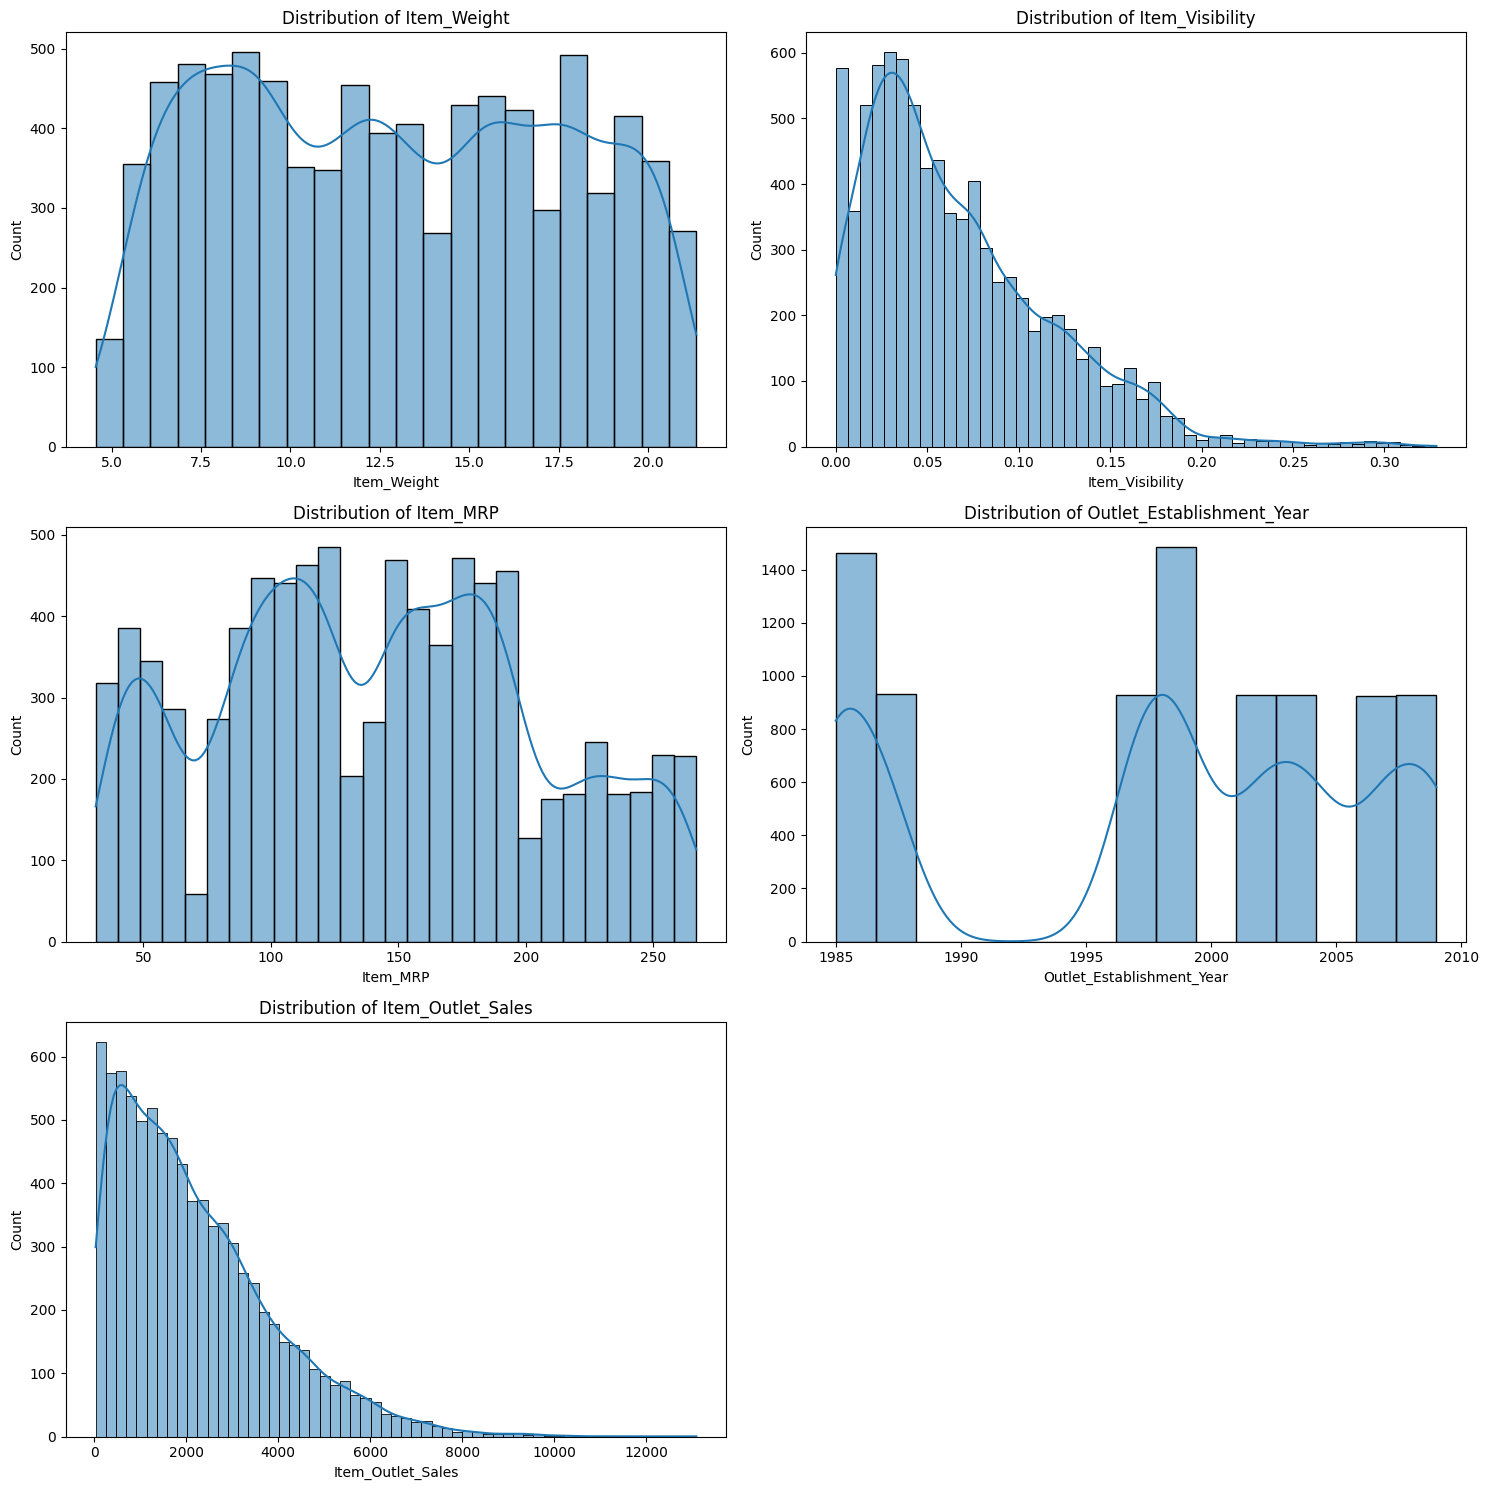

In [16]:
n_rows = math.ceil(len(numeric_cols) / 2)

fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

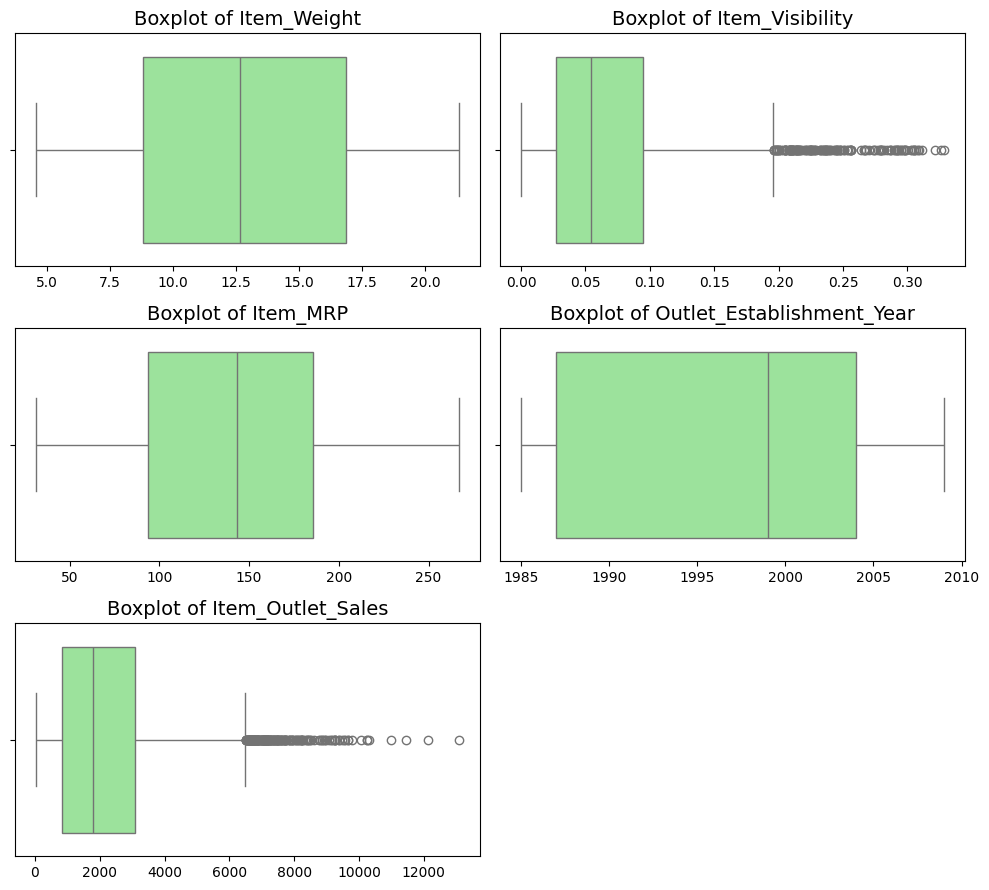

In [17]:
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(10, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

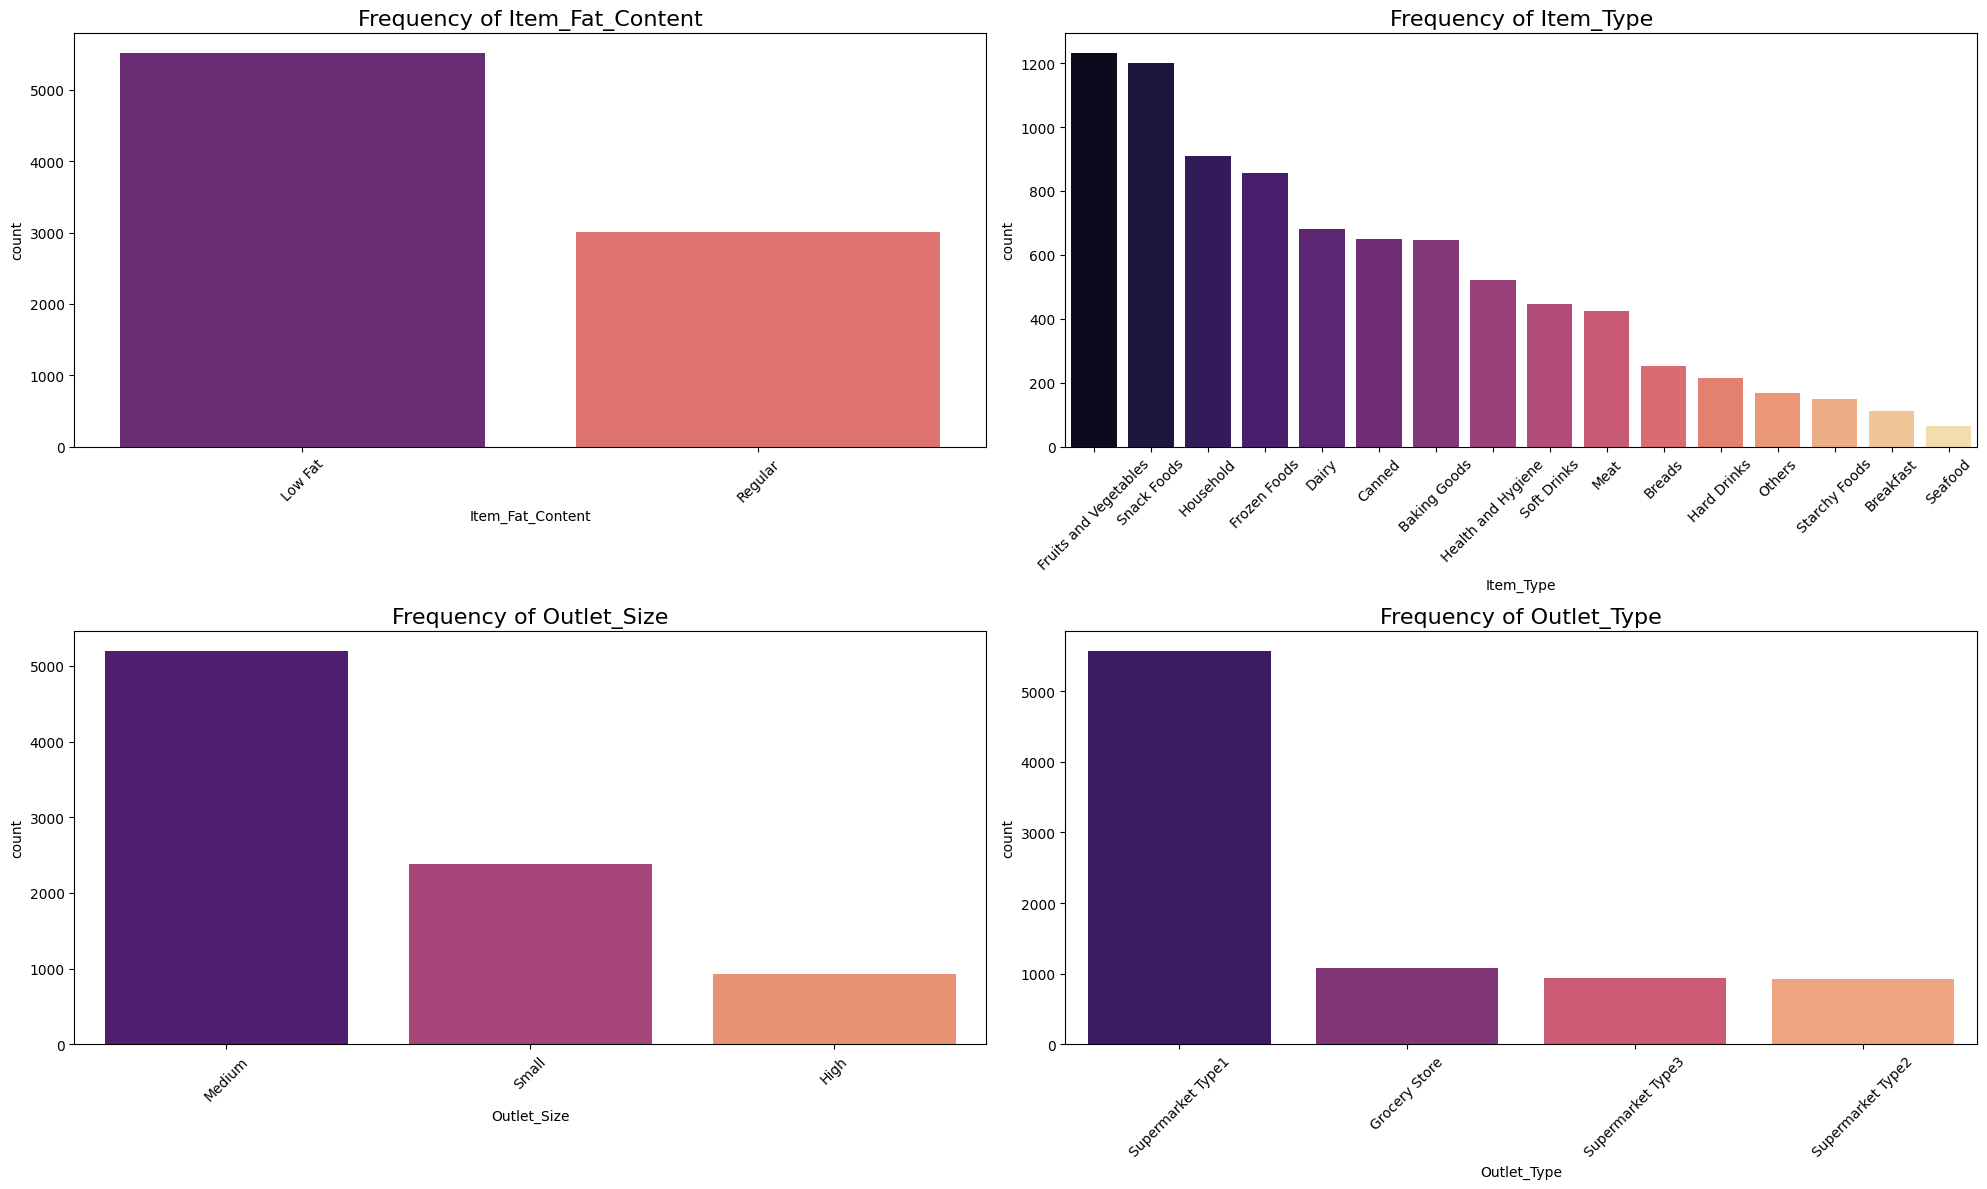

In [18]:
top_cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Type']
n_rows = 2
n_cols = 2

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(top_cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='magma')
    axes[i].set_title(f'Frequency of {col}', fontsize=16)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

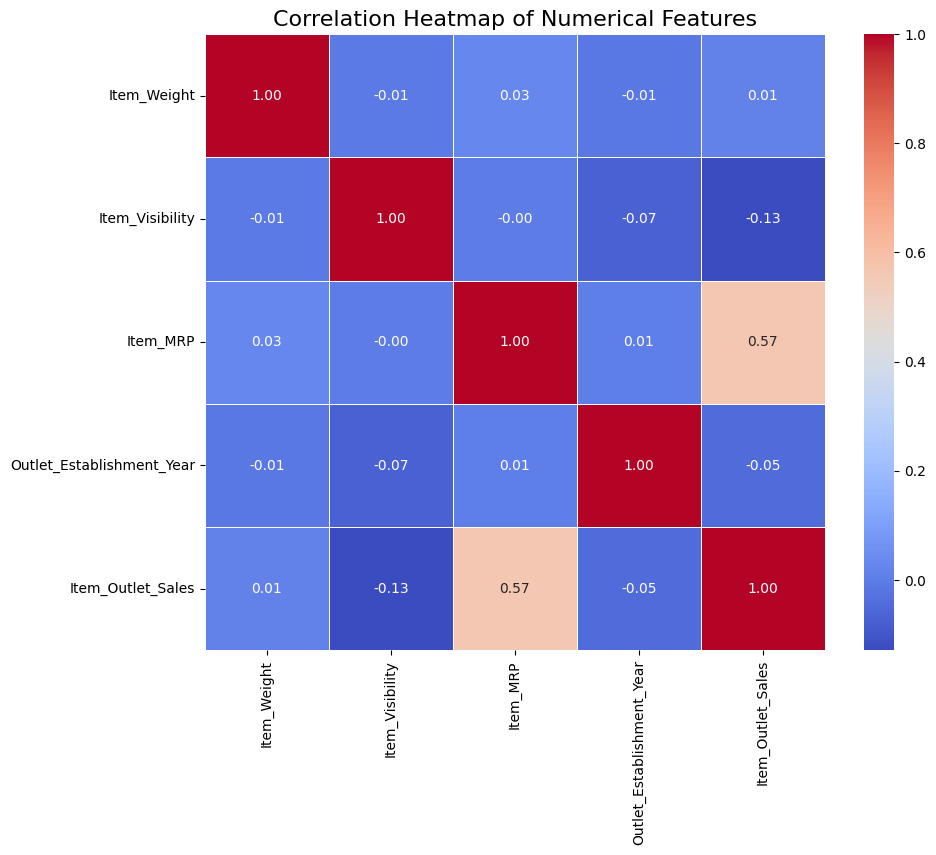

In [19]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

#Feature Inspection


In [20]:
#Remove the placeholders you added in week 2 and replace them with null values.

df_origin = pd.read_csv('https://drive.google.com/uc?id=1syH81TVrbBsdymLT_jl2JIf6IjPXtSQw')

df['Item_Weight'] = df_origin['Item_Weight']
df['Outlet_Size'] = df_origin['Outlet_Size']


df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [21]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


# TO DO: add the new print statements from explore_categorical
def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

#1. Item_Weight : Weight of product

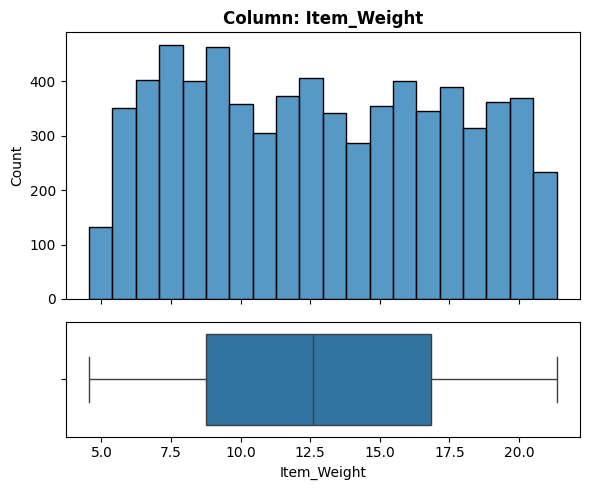

- NaN's Found: 1463 (17.17%)
- Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Item_Weight'}, xlabel='Item_Weight', ylabel='Count'>,
        <Axes: xlabel='Item_Weight'>], dtype=object))

In [22]:
explore_numeric(df, 'Item_Weight', figsize=(6,5) )

What type of feature is it? Numeric.

How many null values? What percentage? What would you do with them?
1,463 (17.17%). I will Impute them using the mean weight per Item_Identifier.

Is the feature constant or quasi-constant? No.

What is the cardinality? Is it high (>10)? Not applicable (Numeric Feature).

Would we know this feature before the target is determined? Yes.

Is there a business case/understanding reason to exclude?  No. While weight might be beyond the immediate control of a store manager, it is a logistics feature that could help in predicting.


#2. Item_Fat_Content : Whether the product is low-fat or *regular*

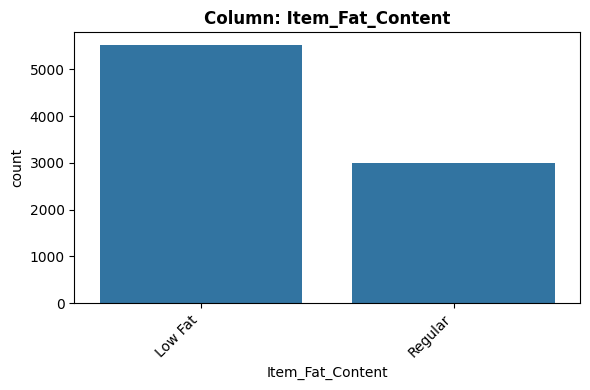

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Fat_Content'}, xlabel='Item_Fat_Content', ylabel='count'>)

In [23]:
explore_categorical(df, 'Item_Fat_Content')

1)What type of feature is it?

Categorical (nominal).

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)

0 null values (0.0%).

3)Is the feature constant or quasi-constant?

No.

4)What is the cardinality? Is it high (>10)?

2 (Low).

5)Would we know this feature before the target is determined?

Yes.

6)Is there a business case/understanding reason to exclude based on our business case?

No. The feature is a standard product attribute that is helpful in predicting sales based on consumer health preferences.

#3. Item_Visibility : The percentage of total display area of all products in a store allocated to the particular product

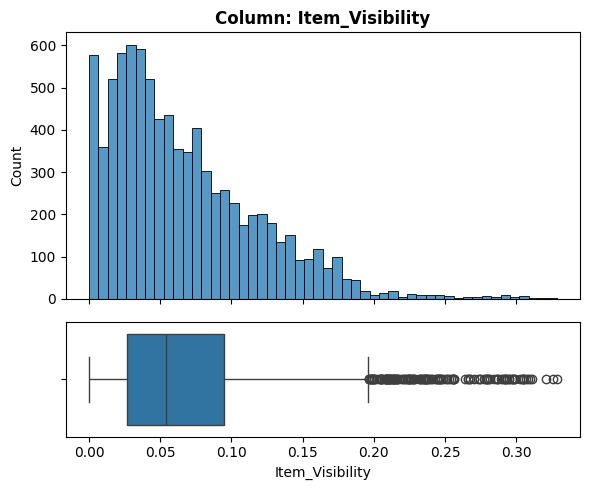

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [24]:
explore_numeric(df, 'Item_Visibility');

1)What type of feature is it? Numeric.

2)How many null values? What percentage? What would you do with them?

0 null values (0.0%).

3)Is the feature constant or quasi-constant? No.

4)What is the cardinality? Is it high (>10)? Not applicable  (Numeric Feature).

5)Would we know this feature before the target is determined? Yes.

6)Is there a business case/understanding reason to exclude?

No. (Product placement and visibility on shelves are key factors that influence customer purchasing decisions).

#4. Item_Type: The category to which the product belongs.

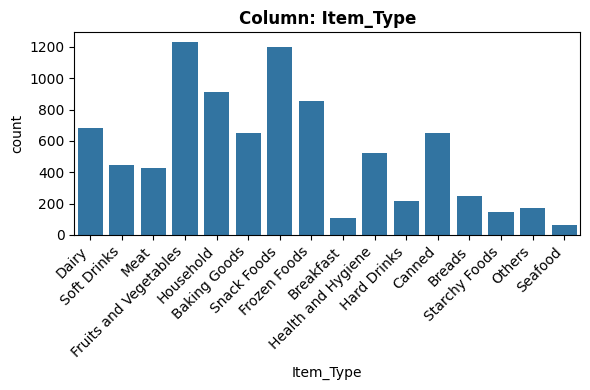

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Type'}, xlabel='Item_Type', ylabel='count'>)

In [27]:
explore_categorical(df, 'Item_Type')

1) What type of feature is it?

    Categorical (nominal).

2) How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)

    0 null values (0.0%).

3) Is the feature constant or quasi-constant?

    No.

4) What is the cardinality? Is it high (>10)?

   16 (High cardinality).

5) Would we know this feature before the target is determined?

     Yes.

6) Is there a business case/understanding reason to exclude based on our business case?

    No. Different product categories naturally have different sales patterns and price ranges.

#5. Item_MRP: Maximum Retail Price (list price) of the product.

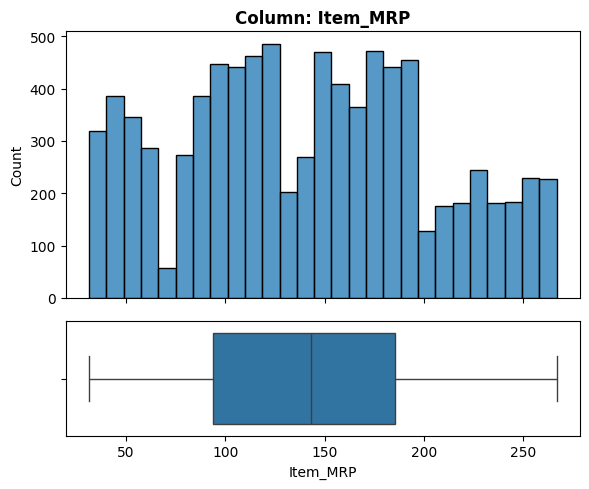

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Item_MRP'}, xlabel='Item_MRP', ylabel='Count'>,
        <Axes: xlabel='Item_MRP'>], dtype=object))

In [26]:
explore_numeric(df, 'Item_MRP')

1)What type of feature is it?  
Numeric.

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)

0 null values (0.0%).

3)Is the feature constant or quasi-constant?

No.

4)What is the cardinality? Is it high (>10)?

Not applicable (Numeric feature).

5)Would we know this feature before the target is determined?

Yes.

6)Is there a business case/understanding reason to exclude based on our business case?

No. Price is one of the most critical factors influencing consumer demand and total sales revenue.

#6. Outlet_Identifier:store ID.

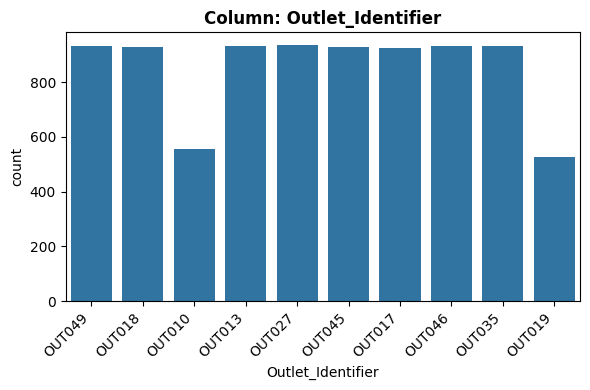

- NaN's Found: 0 (0.0%)
- Unique Values: 10
- Most common value: 'OUT027' occurs 935 times (10.97%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Outlet_Identifier'}, xlabel='Outlet_Identifier', ylabel='count'>)

In [29]:
explore_categorical(df, 'Outlet_Identifier')

1)What type of feature is it?  

Categorical (nominal).

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)

0 null values (0.0%).

3)Is the feature constant or quasi-constant?

No.

4)What is the cardinality? Is it high (>10)?

It is not considered high cardinality because it is exactly 10.

5)Would we know this feature before the target is determined?

Yes.

6)Is there a business case/understanding reason to exclude based on our business case?

No. The specific store location and management are major factors in sales performance.

#7. Outlet_Establishment_Year: The year in which store was established




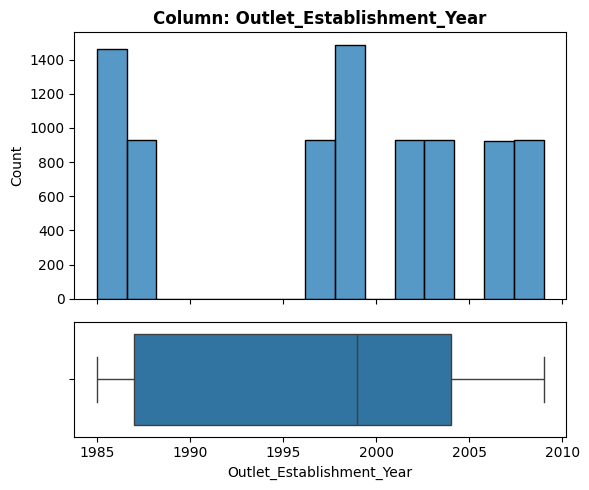

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: '1985' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Outlet_Establishment_Year'}, xlabel='Outlet_Establishment_Year', ylabel='Count'>,
        <Axes: xlabel='Outlet_Establishment_Year'>], dtype=object))

In [30]:
explore_numeric(df, 'Outlet_Establishment_Year')

1)What type of feature is it?
Numeric.

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
0 null values (0.0%).

3)Is the feature constant or quasi-constant?
No.

4)What is the cardinality? Is it high (>10)?
Not applicable (Numeric feature).

5)Would we know this feature before the target is determined?
Yes.

6)Is there a business case/understanding reason to exclude based on our business case?
No. The age of a store reflects its "brand equity" and experience in the market; older stores often have a more established and loyal customer base.

#8. Outlet_Size: The size of the store in terms of ground area covered.

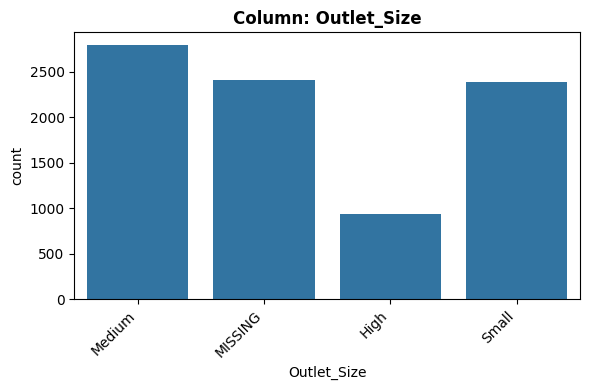

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Outlet_Size'}, xlabel='Outlet_Size', ylabel='count'>)

In [31]:
explore_categorical(df, 'Outlet_Size')

1)What type of feature is it?
Categorical (Ordinal).

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)

2,410 null values (28.28%). I will Impute them using the most frequent value (Mode) or by investigating the relationship with Outlet_Type.

3)Is the feature constant or quasi-constant?
No.

4)What is the cardinality? Is it high (>10)?
3 (Low). The categories are Small, Medium, and High.

5)Would we know this feature before the target is determined?
Yes.

6)Is there a business case/understanding reason to exclude based on our business case?
No. Store size is a key factor in how much inventory a location can hold and how many customers it can serve at once.

#9. Outlet_Location_Type: The type of city in which the store is located.

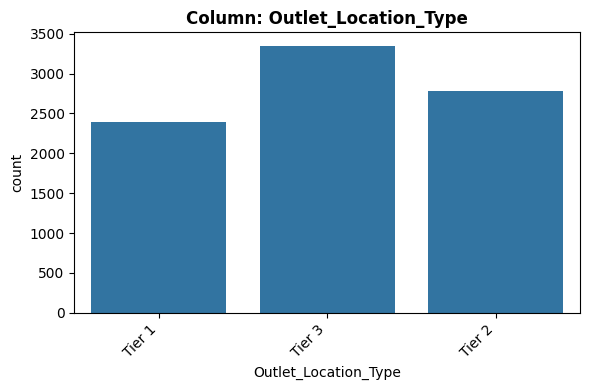

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Outlet_Location_Type'}, xlabel='Outlet_Location_Type', ylabel='count'>)

In [32]:
explore_categorical(df, 'Outlet_Location_Type')

1)What type of feature is it?
Categorical (Ordinal).

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
0 null values (0.0%).

3)Is the feature constant or quasi-constant?
No.

4)What is the cardinality? Is it high (>10)?
3 (Low).

5)Would we know this feature before the target is determined?
Yes.

6)Is there a business case/understanding reason to exclude based on our business case?
No. The economic status and population density of a city (represented by Tiers) are major drivers of consumer spending power.

#10. Outlet_Type: Whether the outlet is a grocery store or some sort of supermarket.

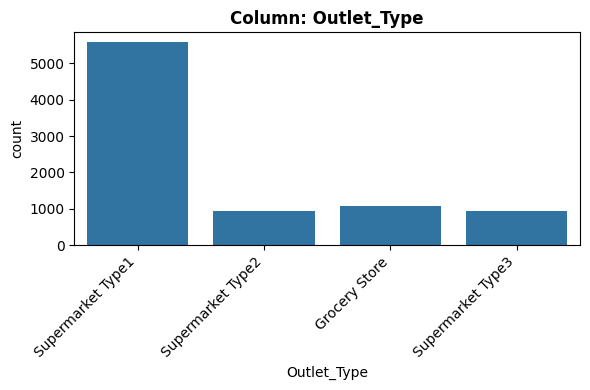

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Outlet_Type'}, xlabel='Outlet_Type', ylabel='count'>)

In [33]:
explore_categorical(df, 'Outlet_Type')

1)What type of feature is it?
Categorical (Nominal).

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
0 null values (0.0%).

3)Is the feature constant or quasi-constant?
No.

4)What is the cardinality? Is it high (>10)?
4 (Low).

5)Would we know this feature before the target is determined?
Yes.

6)Is there a business case/understanding reason to exclude based on our business case?
No. The business model of the store (e.g., a small corner grocery vs. a massive supermarket) is a primary driver of how much stock can be sold.

#11. Item_Outlet_Sales: Sales of the product in the particular store. This is the target variable to be predicted.

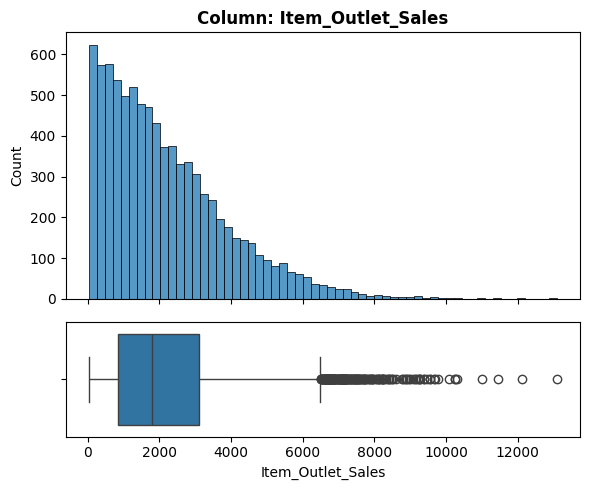

- NaN's Found: 0 (0.0%)
- Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Item_Outlet_Sales'}, xlabel='Item_Outlet_Sales', ylabel='Count'>,
        <Axes: xlabel='Item_Outlet_Sales'>], dtype=object))

In [34]:
explore_numeric(df, 'Item_Outlet_Sales')

1)What type of feature is it?
Numeric.

2)How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
0 null values (0.0%).

3)Is the feature constant or quasi-constant?
No.

4)What is the cardinality? Is it high (>10)?
Not applicable (Numeric feature).

5)Would we know this feature before the target is determined?
No. (This is the target itself; we only know the sales figures after they have occurred).

6)Is there a business case/understanding reason to exclude based on our business case?
No. This is the dependent variable we are trying to predict.

In [46]:
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4),
                           ):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

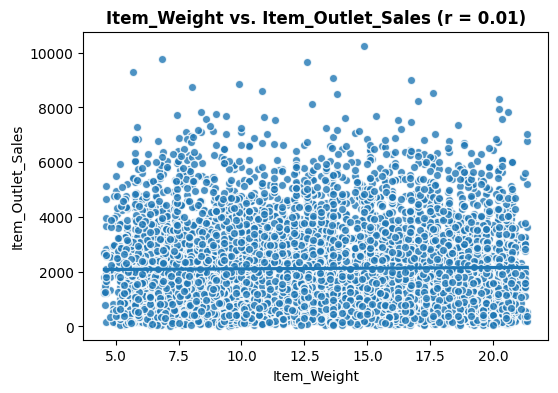

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Weight vs. Item_Outlet_Sales (r = 0.01)'}, xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>)

In [47]:
plot_numeric_vs_target(df, x='Item_Weight')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

No. Usually, the weight of a product doesn't influence how much of it people buy.

2)Does this feature appear to be a predictor of the target?

No. The correlation is almost zero (r = 0.01) and the regression line is flat, showing no relationship.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

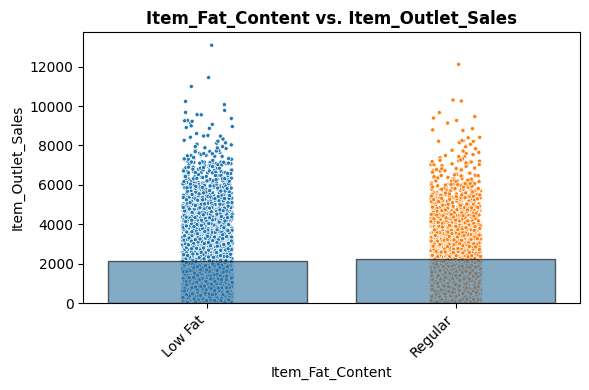

In [48]:
plot_categorical_vs_target(df, x='Item_Fat_Content')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. Some customers prefer healthy (Low Fat) options, while others prefer regular ones.

2)Does this feature appear to be a predictor of the target?

No. The average sales for 'Low Fat' and 'Regular' are almost identical in the plot, showing that fat content doesn't significantly change the total sales.

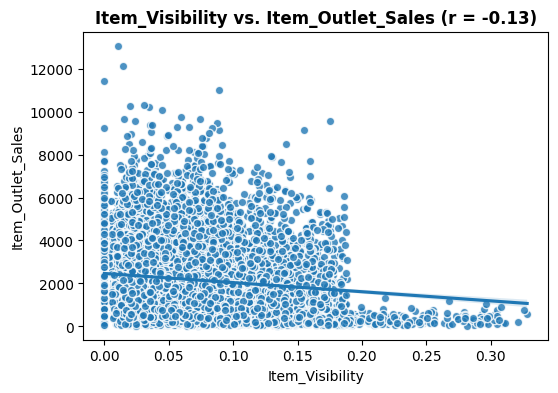

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Visibility vs. Item_Outlet_Sales (r = -0.13)'}, xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>)

In [49]:
plot_numeric_vs_target(df, x='Item_Visibility')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. Products placed at eye level or in more visible areas of the store usually sell more than those hidden away.

2)Does this feature appear to be a predictor of the target?

No. Surprisingly, the correlation is very weak and slightly negative (r = -0.13). This suggests that high visibility doesn't automatically guarantee higher sales in this specific dataset.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Type vs. Item_Outlet_Sales'}, xlabel='Item_Type', ylabel='Item_Outlet_Sales'>)

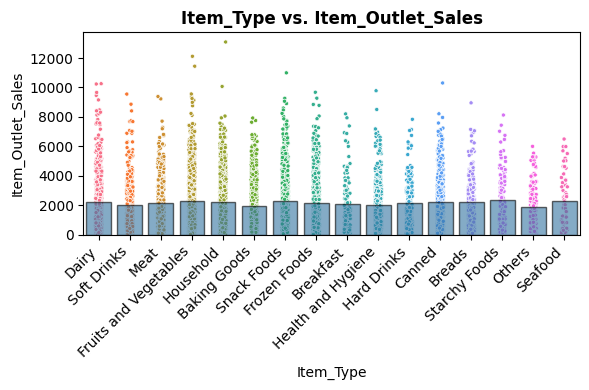

In [50]:
plot_categorical_vs_target(df, x='Item_Type')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. I would expect certain categories, like "Fruits and Vegetables" or "Household items," to have higher demand and sales than others.

2)Does this feature appear to be a predictor of the target?

No. While there are many categories, the mean sales (bar heights) are very similar across most of them. No single category shows a significant advantage in sales.

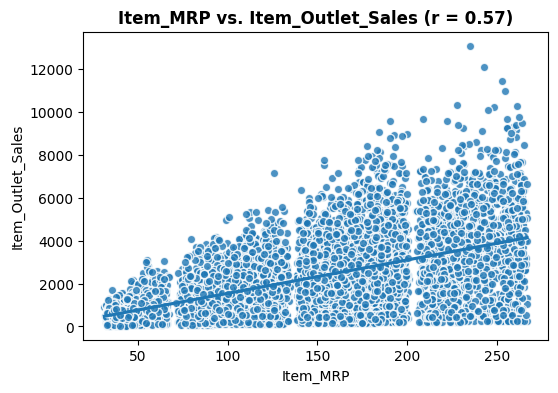

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_MRP vs. Item_Outlet_Sales (r = 0.57)'}, xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>)

In [51]:
plot_numeric_vs_target(df, x='Item_MRP')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. Higher-priced items (High MRP) naturally contribute more to the total sales value than low-priced items.

2)Does this feature appear to be a predictor of the target?

Yes. There is a strong positive correlation (r = 0.57). As the MRP increases, the total sales clearly increase. The scatter plot shows the data points following an upward trend, and the regression line has a clear positive slope.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Identifier vs. Item_Outlet_Sales'}, xlabel='Outlet_Identifier', ylabel='Item_Outlet_Sales'>)

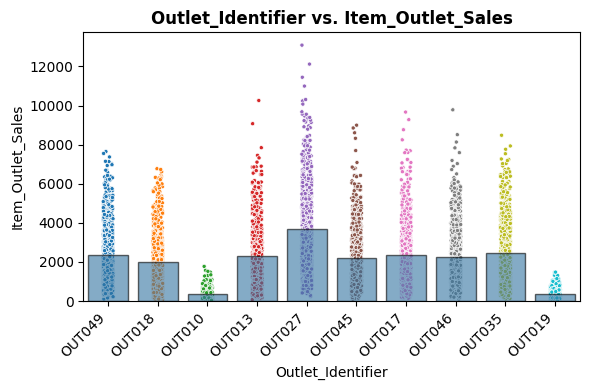

In [54]:
plot_categorical_vs_target(df, x='Outlet_Identifier')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. The performance of a store depends on its specific location, management, and size. Some branches are expected to outperform others.

2)Does this feature appear to be a predictor of the target?

Yes. There are clear differences in the bar heights. For example, some outlets like OUT010 and OUT019 have much lower average sales compared to others, which shows that the specific branch is a strong predictor of sales.

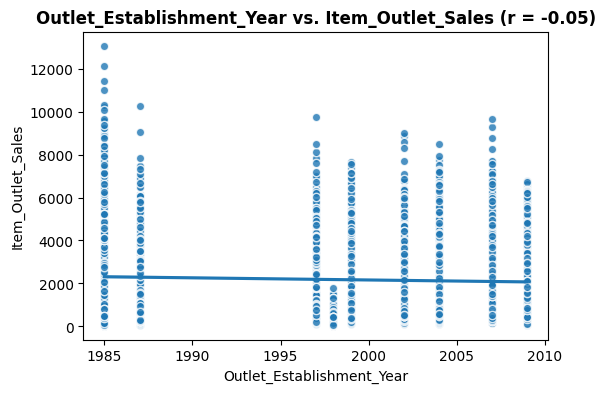

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Establishment_Year vs. Item_Outlet_Sales (r = -0.05)'}, xlabel='Outlet_Establishment_Year', ylabel='Item_Outlet_Sales'>)

In [55]:
plot_numeric_vs_target(df, x='Outlet_Establishment_Year')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. Older, well-established stores might have a more loyal customer base and higher sales than newly opened ones.

2)Does this feature appear to be a predictor of the target?

No. The correlation is almost zero (r = -0.05), and the regression line is flat. This indicates that the age of the store does not directly determine its sales performance in this dataset.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Size vs. Item_Outlet_Sales'}, xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>)

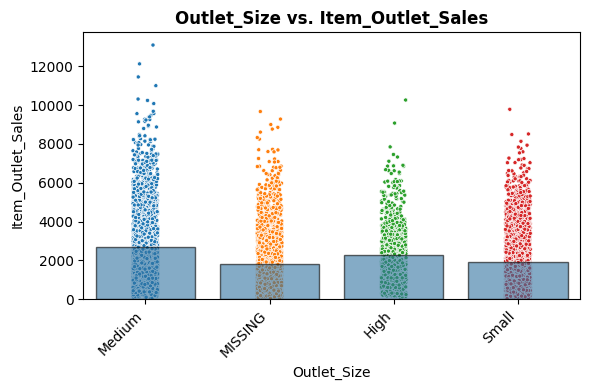

In [56]:
plot_categorical_vs_target(df, x='Outlet_Size')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. Larger stores (Medium or High) usually carry more inventory and can accommodate more customers, likely leading to higher sales.

2)Does this feature appear to be a predictor of the target?

Yes. Medium-sized stores appear to have the highest average sales. Interestingly, the "MISSING" category also shows large sales, suggesting these stores might belong to one of the higher-performing size groups.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Location_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>)

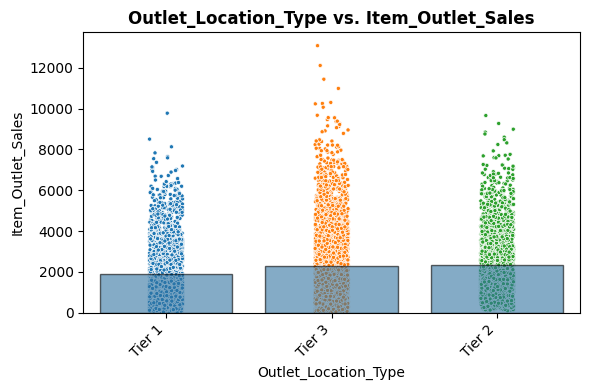

In [57]:
plot_categorical_vs_target(df, x='Outlet_Location_Type')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. Stores in Tier 2 or Tier 3 cities might have different customer purchasing power or competition levels compared to Tier 1 cities.

2)Does this feature appear to be a predictor of the target?

Yes. The plot shows that Tier 2 locations have slightly higher average sales. There is a noticeable difference between the tiers, making the location type a useful predictor.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Type', ylabel='Item_Outlet_Sales'>)

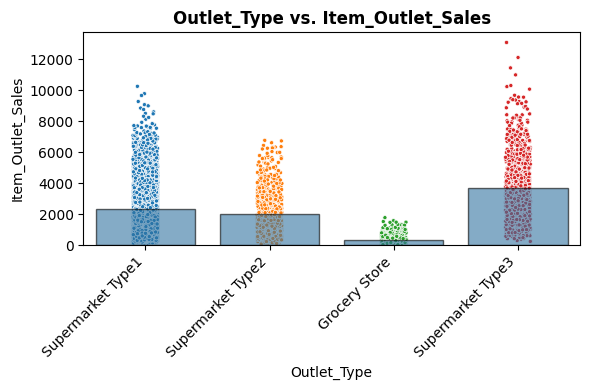

In [58]:
plot_categorical_vs_target(df, x='Outlet_Type')

1)Based on your business understanding, would you expect this feature to be a predictor of the target?

Yes. A "Grocery Store" is much smaller and has less variety than a "Supermarket Type3," so their sales should be very different.

2)Does this feature appear to be a predictor of the target?

Yes. This is a very strong predictor. The Supermarket Type3 has the highest average sales by far, while Grocery Stores have the lowest. The differences between categories are very clear and significant.